In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt

In [2]:
rootfolder = '..'

Useful function for plot the dictionary

In [3]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Set all the parameters for the anomaly detection

In [4]:
# patch size (tha patch is square)
p = 15

# number of patches in the training set for dictionary learning
npatch_dictionary = 10000

# number of patches to estimate the confidence region
npatch_region = 1000

# parameters for the dictionary learning using the KSVD
niter_dl = 10
natom = int(np.round(p**2*1.5))
L = 4

# regularization parameters for the l1 sparse coding
lmbda = 0.18

Construct the training and validation sets
------------------------------------------

In [5]:
# load the training image and rescale it in [0,1]
img = imread(f'{rootfolder}/data/img_normal.png') / 255

# extract random patches from the image and store them in a matrices S
# S is obtained by randomly extracting patches from the anomaly-free image
S = np.zeros((p * p, npatch_dictionary))
for i in range(npatch_dictionary):
    x = np.random.randint(0, img.shape[0] - p + 1)
    y = np.random.randint(0, img.shape[1] - p + 1)
    patch = img[x : x+p, y : y+p].flatten()
    S[:, i] = patch

# extract random patches from the image and store them in a matrices V
# V is obtained by randomly extracting patches from the anomaly-free image
V = np.zeros((p * p, npatch_region))
for i in range(npatch_region):
    x = np.random.randint(0, img.shape[0] - p + 1)
    y = np.random.randint(0, img.shape[1] - p + 1)
    patch = img[x : x+p, y : y+p].flatten()
    V[:, i] = patch

Dictionary Learning
-------------------
Perform preprocessing on the patches in $S$

In [6]:
# exclude black patches from S
v = np.median(S, axis=0)
S = S[:, v > 0.06]

# remove the mean from each patch
S = S - np.mean(S, axis=0)

Perform dictionary learning via KSVD

In [7]:
def OMP(s, D, L, tau):
    M, N = D.shape
    x_OMP = np.zeros(N)

    # residual
    r = s.copy()

    # support set
    omega = []

    while np.count_nonzero(x_OMP) < L and np.linalg.norm(r, ord=2) > tau:
        # compute the residual wrt each column of D
        e = np.zeros(N)
        for j in range(N):
            e[j] = (np.linalg.norm(r, ord=2) ** 2) - (r.T @ D[:, j]) ** 2

        # find the column of D that matches at best r
        jStar = np.argmin(e)

        # update the support set with the jStar coefficient
        if jStar not in omega:
            omega.append(jStar)
        else:
            break

        # update the coefficients by solving the least square problem min ||D_omega x - s||
        D_omega = D[:, omega]
        x = np.linalg.solve(D_omega.T @ D_omega, D_omega.T @ s)
        x_OMP[omega] = x

        # update the residual
        r = s - D @ x_OMP

    return x_OMP

def ksvd(S, M, N, max_iter, npatch, L):
    # intialize the dictionary
    D = np.random.randn(M, N)

    # normalize each column of D (zero mean and unit norm)
    D = D - np.mean(D, axis=0, keepdims=True)
    D = D / np.linalg.norm(D, axis=0, keepdims=True)

    # initialize the coefficient matrix
    X = np.zeros((N, npatch))

    # main KSVD loop
    for iter in range(max_iter):
        # perform the sparse coding via OMP of all the columns of S
        for n in range(npatch):
            X[:, n] = OMP(S[:, n], D, L, tau=1e-6)

        # dictionary update step
        for j0 in range(N):
            # find which signals uses the j-th atom in the sparse coding
            omega = []
            for i in range(npatch):
                if X[j0, i] != 0:
                    omega.append(i)

            if len(omega) == 0:
                # if the atom is never used then ignore or substitute it with a random vector
                D[:, j0] = np.random.randn(M)
                D[:, j0] = D[:, j0] - np.mean(D[:, j0])
                D[:, j0] = D[:, j0] / np.linalg.norm(D[:, j0])
            else:
                # compute the residual matrix E, ignoring the j-th atom
                E = S - D @ X + np.outer(D[:, j0], X[j0, :])

                # restrict E to the columns indicated by omega
                Eomega = E[:, omega]

                # compute the best rank-1 approximation
                U, Sigma, Vt = np.linalg.svd(Eomega, full_matrices=False)

                # update the dictionary
                D[:, j0] = U[:, 0]

                # update the coefficient matrix
                X[j0, omega] = Sigma[0] * Vt[0, :]

    return D

Perform dictionary learning via MOD

In [8]:
def FISTA(s, D, lmbda, x0=None, MAX_ITER=200, TOL_DIST_X=1e-5, gamma=None):
    if x0 is None:
        x = np.zeros(D.shape[1])
    else:
        x = x0.copy()

    # initialize extrapolated point
    y = x.copy()

    # initialize FISTA momentum parameter
    t = 1.0

    # initialize stopping criterion and iteration counter
    distanceX = 1e10
    cnt = 0

    # precompute constant matrices/vectors
    DtD = D.T @ D
    Dts = D.T @ s

    # compute step size if not provided
    if gamma is None:
        gamma = 1 / np.max(np.linalg.eigvalsh(DtD))
        
    # gradient of the smooth term 1/2 ||D x - s||_2^2
    df = lambda x: DtD @ x - Dts

    while cnt < MAX_ITER and distanceX > TOL_DIST_X:
        # store previous estimate
        x_old = x.copy()

        # compute the argument of the proximal operator from the extrapolated point
        x_gd = y - gamma * df(y)

        # perform soft thresholding
        x_current = np.sign(x_gd) * np.maximum(np.abs(x_gd) - gamma * lmbda, 0.0)

        # update FISTA momentum parameter
        t_current = (1 + np.sqrt(1 + 4 * t**2)) / 2

        # update extrapolated point
        y = x_current + ((t - 1) / t_current) * (x_current - x_old)

        # compute the distance between two consecutive iterates for stopping criterion
        distanceX = np.linalg.norm(x_current - x_old)

        # update current estimate and momentum parameter
        x = x_current
        t = t_current

        cnt += 1

    return x

def MOD(S, N, lmbda, max_iter=10, eps=1e-6):
    M, npatch = S.shape

    # init dictionary
    D = np.random.randn(M, N)
    D = D - np.mean(D, axis=0, keepdims=True)
    norms = np.linalg.norm(D, axis=0, keepdims=True)
    norms[norms < 1e-12] = 1.0
    D = D / norms

    # init coefficient matrix
    X = np.zeros((N, npatch))

    for _ in range(max_iter):
        # perform the sparse coding for all the patches in S
        for n in range(npatch):
            X[:, n] = FISTA(S[:, n], D, lmbda)

        # MOD dictionary update
        A = X @ X.T + eps * np.eye(N)
        B = S @ X.T
        
        D = np.linalg.solve(A.T, B.T).T

        # normalize the column
        norms = np.linalg.norm(D, axis=0, keepdims=True)
        norms[norms < 1e-12] = 1.0
        D = D / norms

    return D

In [9]:
# perform dictionary learning via KSVD
# D = ksvd(S, M=p*p, N=natom, max_iter=niter_dl, npatch=S.shape[1], L=L)

# or perform dictionary learning via MOD
# D = MOD(S, N=natom, lmbda=0.7, max_iter=10)

# or load a precomputed dictionary
D = loadmat(f'{rootfolder}/data/dict_anom_det.mat')['D']

Show the learned dictionary

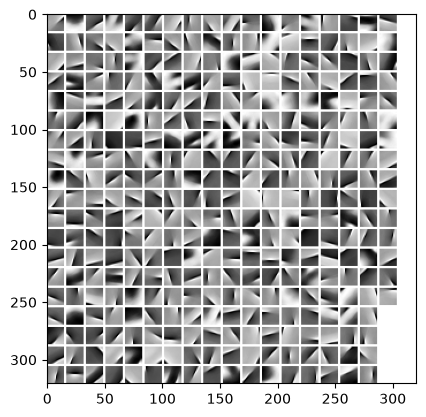

In [10]:
img_dict = get_dictionary_img(D)
plt.imshow(img_dict, cmap='gray')
plt.show()

## Confidence region estimation / density estimation

In [11]:
# exclude black patches
v = np.median(V, axis=0)
V = V[:, v > 0.06]

# remove the mean from each patch
V = V - np.mean(V, axis=0)

In [12]:
# sparse coding of each patch in V
X = np.zeros((D.shape[1], V.shape[1]))

for i in range(V.shape[1]):
    X[:, i] = FISTA(V[:, i], D, lmbda)

In [13]:
# computing the anomaly indicators (reconstruction error, l1 norm) for each patch in V
# each column contains the values of the anomaly_scores for a patch
A = np.zeros((2, V.shape[1]))

for i in range(V.shape[1]):
    A[:,i] = [np.linalg.norm(V[:, i] - D @ X[:, i], ord=2), np.linalg.norm(X[:, i], ord=1)]

# estimation of mean and covariance
mu = np.mean(A, axis=1)
Sigma = np.cov(A)

In [14]:
# estimation of the threshold that gives the desired false positive rate using the patches in V
FPR_target = 0.1

# compute Sigma inverse
Sigma_inv = np.linalg.pinv(Sigma)

# compute the Mahalanobis distance for each indicator vector in A
mahal_dist = np.zeros(V.shape[1])
for i in range(A.shape[1]):
    mahal_dist[i] = (A[:, i] - mu).T @ Sigma_inv @ (A[:, i] - mu)

# set the threshold
threshold = np.percentile(mahal_dist, 100 * (1 - FPR_target))

## Test phase

In [15]:
# load the test image
img_test = imread(f'{rootfolder}/data/img_anom.png') / 255
imsz = img_test.shape

STEP = 7

# initialize the estimated image
heatmap = np.zeros_like(img_test)

# initialize the weight matrix
weights = np.zeros_like(img_test)

In [16]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = img_test[i : i+p, j : j+p].flatten()

        # if the median of s is to small set the anomaly score to 0
        if np.median(s) <= 0.06:
            score = 0
        else:
            # subratct the mean to the patch
            s = s - np.mean(s)

            # perform the sparse coding
            x = FISTA(s, D, lmbda)

            # compute the anomaly indicators vector
            a = np.array([np.linalg.norm(s - D @ x, ord=2), np.linalg.norm(x, ord=1)])

            # compute the anomaly score
            score = (a - mu).T @ Sigma_inv @ (a - mu)

        # update the heatmap
        heatmap[i : i+p, j : j+p] += score

        # update the weight matrix
        weights[i : i+p, j : j+p] += 1

In [17]:
# normalize the heatmap
heatmap_final = np.zeros_like(heatmap)
valid = weights > 0
heatmap_final[valid] = heatmap[valid] / weights[valid]
heatmap = heatmap_final

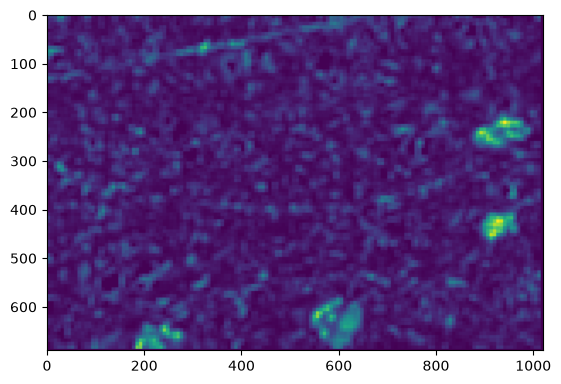

In [18]:
# plot the heatmap
plt.imshow(heatmap)

In [19]:
# build the detection mask, that has the same size of the test image
# each pixel in the mask has value 1 if the corresponding patch has been detected as anomalous, otherwise it has value 0
mask = heatmap > threshold

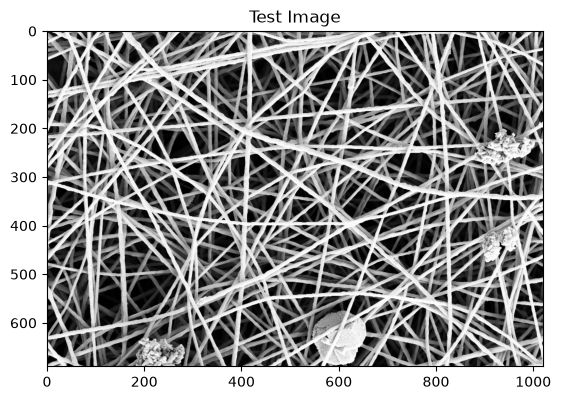

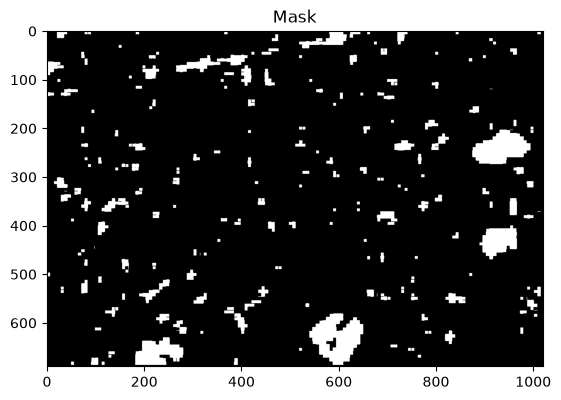

In [20]:
## show the results
plt.figure(3), plt.imshow(img_test, cmap='gray'), plt.title('Test Image')
plt.figure(4), plt.imshow(mask, cmap='gray'), plt.title('Mask')
plt.show()

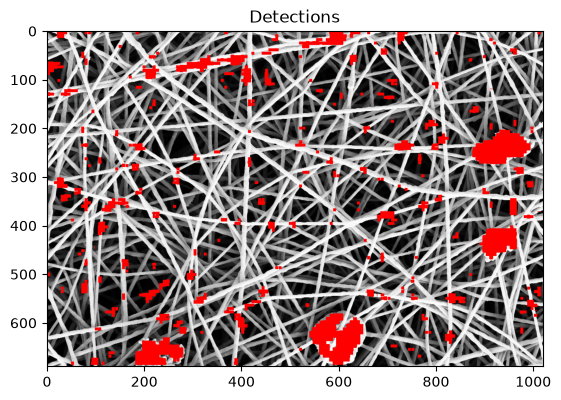

In [21]:
# combine the mask and the test image
img_color = np.zeros([img_test.shape[0], img_test.shape[1], 3])
img_temp = img_test.copy()
img_temp[mask > 0] = 1
img_color[:,:,0] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,1] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,2] = img_temp

plt.figure(5), plt.imshow(img_color), plt.title('Detections')
plt.show()